## Predictive Analysis with Majestic Media


predict if user will cancel membership


## Imports


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# for data prep 
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
# for evaluation
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
#for analysis 
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier


In [4]:
#import data 
df = pd.read_csv('Kaggle_churn_training.csv')
testData = pd.read_csv('Kaggle_churn_test.csv')

## EDA

In [5]:
#Convert datatypes 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2520 entries, 0 to 2519
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer_ID              2520 non-null   int64  
 1   Call_Failure             2245 non-null   float64
 2   Complains                2498 non-null   float64
 3   Subscription_Length      2274 non-null   float64
 4   Charge_Amount            2262 non-null   float64
 5   Seconds_of_use           2132 non-null   float64
 6   Frequency_of_use         2130 non-null   float64
 7   Frequency_of_SMS         2151 non-null   float64
 8   Distinct_Called_Numbers  2134 non-null   float64
 9   Age_Group                2491 non-null   float64
 10  Tariff_Plan              2491 non-null   float64
 11  Status                   2489 non-null   float64
 12  Customer_Value           2397 non-null   float64
 13  Churn                    2520 non-null   int64  
dtypes: float64(12), int64(2)
memory usa

In [6]:
df.head()

,Customer_ID,Call_Failure,Complains,Subscription_Length,Charge_Amount,Seconds_of_use,Frequency_of_use,Frequency_of_SMS,Distinct_Called_Numbers,Age_Group,Tariff_Plan,Status,Customer_Value,Churn
0,19150,8.0,0.0,38.0,0.0,NaN,71.0,NaN,17.0,3.0,1.0,1.0,197.640,0
1,16208,0.0,0.0,39.0,0.0,318.0,5.0,7.0,4.0,2.0,1.0,2.0,46.035,0
2,14115,10.0,0.0,38.0,0.0,4198.0,NaN,1.0,35.0,1.0,1.0,1.0,240.020,0
3,17389,3.0,0.0,38.0,0.0,NaN,58.0,2.0,33.0,1.0,1.0,1.0,145.805,0
4,16790,11.0,0.0,NaN,1.0,3775.0,82.0,32.0,28.0,3.0,1.0,1.0,282.280,0


In [7]:
df['Complains'] = df['Complains'].astype('category') 
df['Charge_Amount'] = df['Charge_Amount'].astype('float64') #temp change to float64 so i can fill median
df['Age_Group'] = df['Age_Group'].astype('category')
df['Tariff_Plan'] = df['Tariff_Plan'].astype('category')
df['Status'] = df['Status'].astype('category')
df['Churn'] = df['Churn']. astype('category')

testData['Complains'] = testData['Complains'].astype('category') 
testData['Charge_Amount'] = testData['Charge_Amount'].astype('float64') #temp change to float64 so i can fill median
testData['Age_Group'] = testData['Age_Group'].astype('category')
testData['Tariff_Plan'] = testData['Tariff_Plan'].astype('category')
testData['Status'] = testData['Status'].astype('category')


In [8]:
#find missing values
df.isna().sum()

Customer_ID                  0
Call_Failure               275
Complains                   22
Subscription_Length        246
Charge_Amount              258
Seconds_of_use             388
Frequency_of_use           390
Frequency_of_SMS           369
Distinct_Called_Numbers    386
Age_Group                   29
Tariff_Plan                 29
Status                      31
Customer_Value             123
Churn                        0
dtype: int64

In [9]:
testData.isna().sum()

Customer_ID                  0
Call_Failure                62
Complains                    4
Subscription_Length         68
Charge_Amount               58
Seconds_of_use              96
Frequency_of_use           104
Frequency_of_SMS            93
Distinct_Called_Numbers     90
Age_Group                    2
Tariff_Plan                  6
Status                       5
Customer_Value              24
dtype: int64

In [10]:
# Handle missing numerical data
df['Call_Failure'] = df['Call_Failure'].fillna(df['Call_Failure'].mean())
df['Subscription_Length'] = df['Subscription_Length'].fillna(df['Subscription_Length'].mean())
df['Seconds_of_use'] = df['Seconds_of_use'].fillna(df['Seconds_of_use'].mean())
df['Frequency_of_use'] = df['Frequency_of_use'].fillna(df['Frequency_of_use'].mean())
df['Frequency_of_SMS'] = df['Frequency_of_SMS'].fillna(df['Frequency_of_SMS'].mean())
df['Distinct_Called_Numbers'] = df['Distinct_Called_Numbers'].fillna(df['Distinct_Called_Numbers'].mean())
df['Customer_Value'] = df['Customer_Value'].fillna(df['Customer_Value'].mean())

testData['Call_Failure'] = testData['Call_Failure'].fillna(testData['Call_Failure'].mean())
testData['Subscription_Length'] = testData['Subscription_Length'].fillna(testData['Subscription_Length'].mean())
testData['Seconds_of_use'] = testData['Seconds_of_use'].fillna(testData['Seconds_of_use'].mean())
testData['Frequency_of_use'] = testData['Frequency_of_use'].fillna(testData['Frequency_of_use'].mean())
testData['Frequency_of_SMS'] = testData['Frequency_of_SMS'].fillna(testData['Frequency_of_SMS'].mean())
testData['Distinct_Called_Numbers'] = testData['Distinct_Called_Numbers'].fillna(testData['Distinct_Called_Numbers'].mean())
testData['Customer_Value'] = testData['Customer_Value'].fillna(testData['Customer_Value'].mean())

In [11]:
# Handle missing Categorical data
df['Complains'].value_counts(dropna=False)

Complains
 0.0    2314
 1.0     184
NaN       22
Name: count, dtype: int64

In [12]:
df['Complains'] = df['Complains'].fillna(0)
testData['Complains'] = testData['Complains'].fillna(0)

In [13]:
df['Charge_Amount'].value_counts(dropna=False)


Charge_Amount
0.0     1284
1.0      423
2.0      289
NaN      258
3.0      136
4.0       61
5.0       19
8.0       13
7.0       12
9.0       10
6.0        9
10.0       6
Name: count, dtype: int64

In [14]:
# Because this is ordinal data, fill with the median.
df['Charge_Amount'] = df['Charge_Amount'].fillna(df['Charge_Amount'].median())
df['Charge_Amount'] = df['Charge_Amount'].astype('category') # change back to category

testData['Charge_Amount'] = testData['Charge_Amount'].fillna(testData['Charge_Amount'].median())
testData['Charge_Amount'] = testData['Charge_Amount'].astype('category') # change back to category


In [15]:
df['Age_Group'].value_counts(dropna=False)


Age_Group
 3.0    1107
 2.0     827
 4.0     312
 5.0     145
 1.0     100
NaN       29
Name: count, dtype: int64

In [16]:
#fill with mode

df['Age_Group'] = df['Age_Group'].fillna(3)
testData['Age_Group'] = testData['Age_Group'].fillna(3)


In [17]:
df['Tariff_Plan'].value_counts(dropna = False)


Tariff_Plan
 1.0    2290
 2.0     201
NaN       29
Name: count, dtype: int64

In [18]:
#fill with mode
df['Tariff_Plan'] = df['Tariff_Plan'].fillna(1)
testData['Tariff_Plan'] = testData['Tariff_Plan'].fillna(1)

In [19]:
df['Status'].value_counts(dropna = False)


Status
 1.0    1878
 2.0     611
NaN       31
Name: count, dtype: int64

In [20]:
#fill with mode
df['Status'] = df['Status'].fillna(1)
testData['Status'] = testData['Status'].fillna(1)

# All values are already encoded. 

## Data Preperation 

In [21]:
## determine what variables are important 


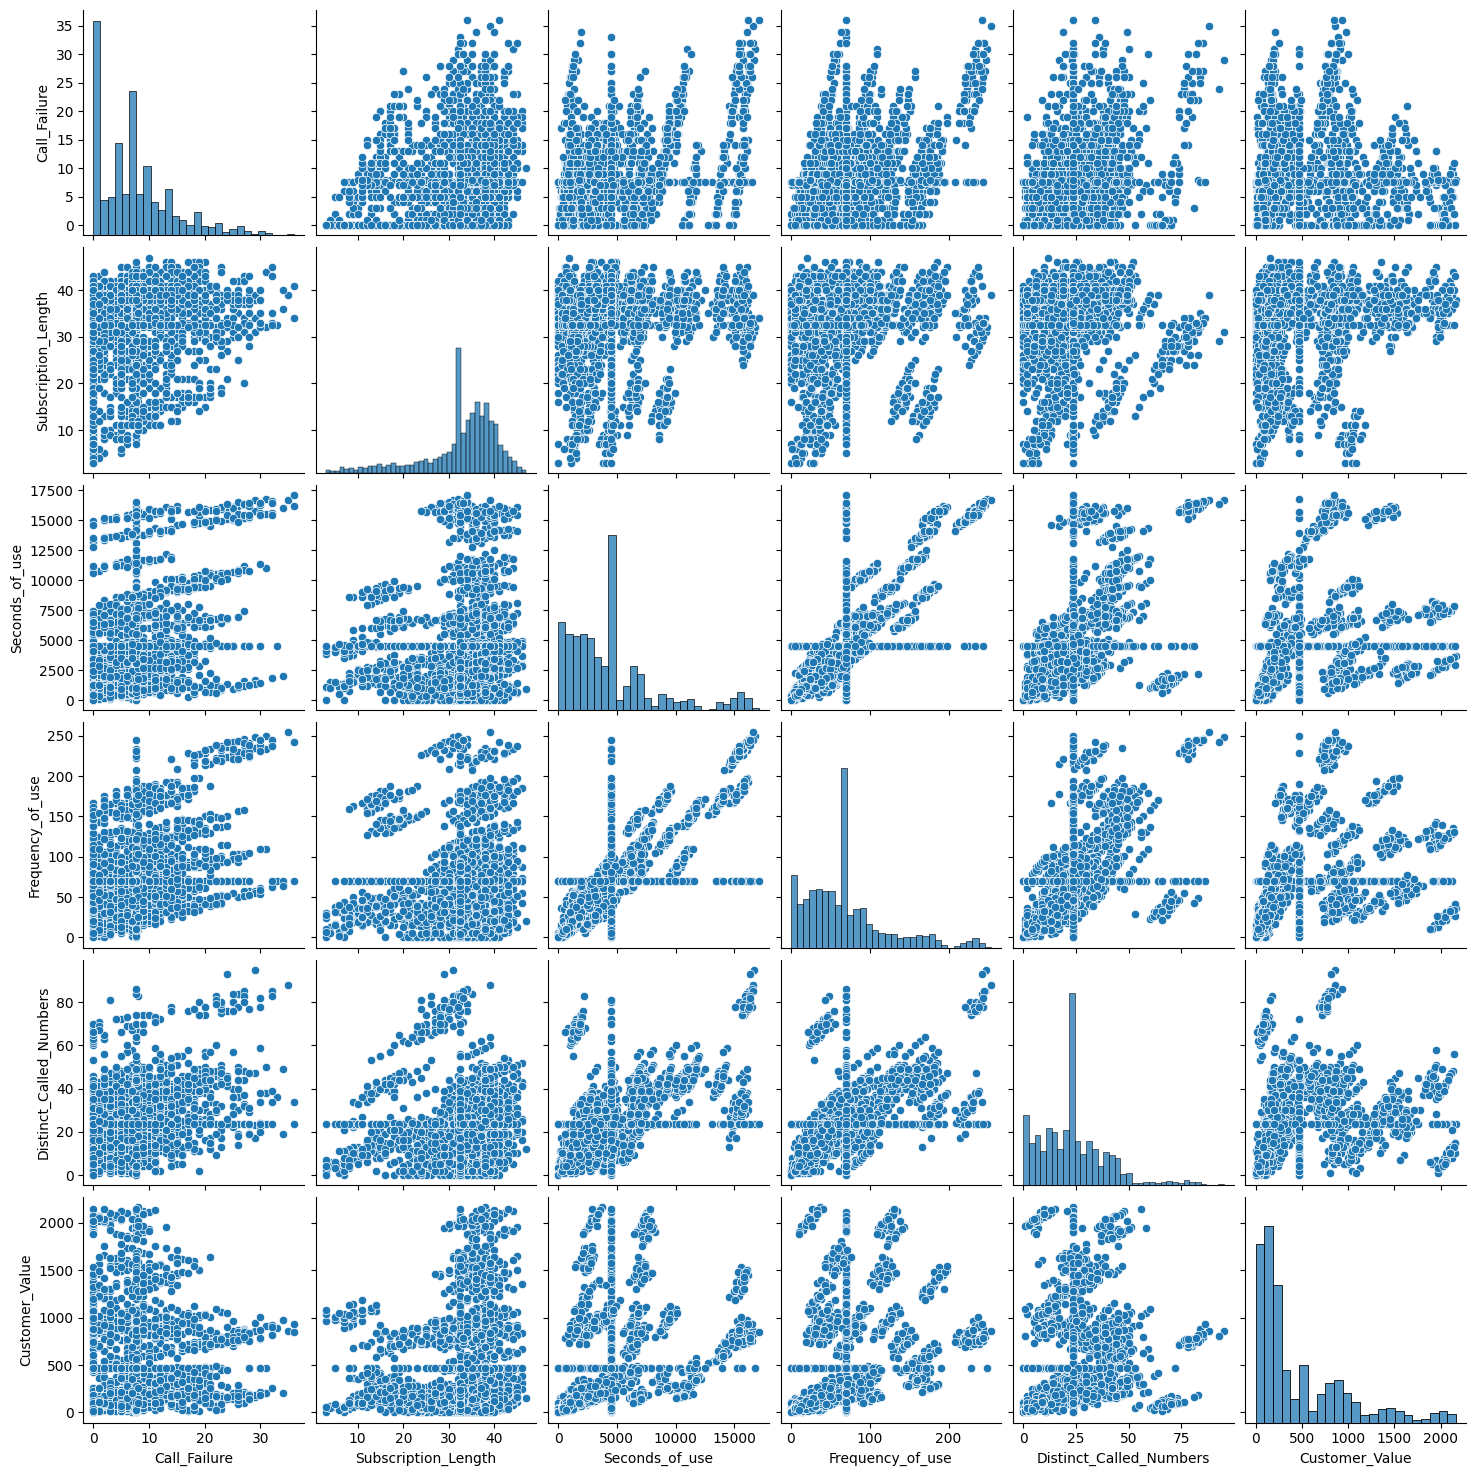

In [22]:
#pairplot of numerical variables
sns.pairplot(df[['Call_Failure', 
                 'Subscription_Length', 'Seconds_of_use', 
                 'Frequency_of_use', 'Distinct_Called_Numbers', 'Customer_Value']])

In [23]:
features_list = x = ['Call_Failure', 
                 'Subscription_Length', 'Seconds_of_use', 
                 'Frequency_of_use', 'Distinct_Called_Numbers', 'Customer_Value', #These are the numerical variables
                 'Complains','Charge_Amount', 'Age_Group', 'Tariff_Plan', 'Status' # These are the categorical data
                 ]
x = df[features_list]
y = df['Churn'].astype(int)
x_train, x_val, y_train, y_val = train_test_split (x,y, test_size = 0.2, stratify = y, random_state=11)

## Model 1: Gradient Boosting Decision Tree


In [24]:
gbdt_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=11)
gbdt_model.fit(x_train, y_train)
gbdt_pred = gbdt_model.predict(x_val)


In [25]:
# produce confusion matrix 
print (confusion_matrix(y_val, gbdt_pred))
print (classification_report(y_val, gbdt_pred))

[[413  12]
 [ 28  51]]
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       425
           1       0.81      0.65      0.72        79

    accuracy                           0.92       504
   macro avg       0.87      0.81      0.84       504
weighted avg       0.92      0.92      0.92       504



Confusion Matrix:
 [[413  12]
 [ 28  51]]


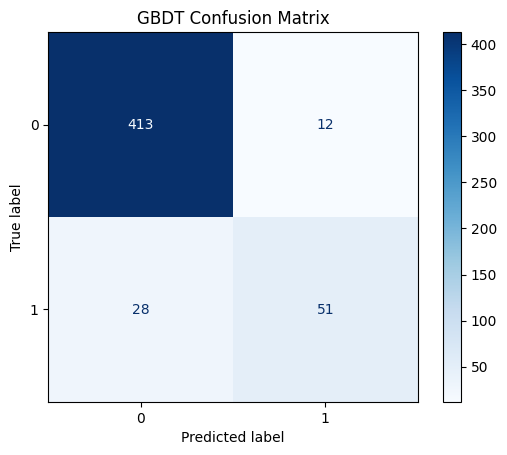

              precision    recall  f1-score   support

           0       0.94      0.97      0.95       425
           1       0.81      0.65      0.72        79

    accuracy                           0.92       504
   macro avg       0.87      0.81      0.84       504
weighted avg       0.92      0.92      0.92       504

Accuracy = 0.9206349206349206
TN = 413
FP = 12
FN = 28
TP = 51
Cost = -2675


In [26]:
# Predictions for Model 1
gbdt_pred = gbdt_model.predict(x_val)

# Confusion matrix
cm_gbdt = confusion_matrix(y_val, gbdt_pred)
print("Confusion Matrix:\n", cm_gbdt)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gbdt, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.title("GBDT Confusion Matrix")
plt.show()

# Classification report
print(classification_report(y_val, gbdt_pred))

# Accuracy
acc_gbdt = accuracy_score(y_val, gbdt_pred)
print("Accuracy =", acc_gbdt)

# TN, FP, FN, TP
tn, fp, fn, tp = cm_gbdt.ravel()
print("TN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)

# Project cost
cost_gbdt = (-50 * fn) + (-25 * tp)
print("Cost =", cost_gbdt)

## Deploy

In [27]:
# Model on the training dataset
final_predict1 = gbdt_model.predict(df[features_list])

submission1 = pd.DataFrame({
    'Customer_ID': df['Customer_ID'],
    'Churn': final_predict1
})

submission1.to_csv('model_1.csv', index= False)

In [28]:

# Model on the testing file 
final_predict0 = gbdt_model.predict(testData[features_list])

submission0 = pd.DataFrame({
    'Customer_ID': testData['Customer_ID'],
    'Churn': final_predict0
})

submission0.to_csv('kaggle_submit.csv', index= False)